# Easy Exercise: A First GAN from Noise to Data

This exercise is based on the GAN demo notebook.

The goal is to understand the core GAN mechanism without using PyTorch or TensorFlow. We train a small generator to imitate a simple two-dimensional data distribution.

## Learning goals

By the end of this exercise, you should be able to explain:

1. what a data distribution is;
2. what latent noise is;
3. what the generator does;
4. what the discriminator does;
5. why binary cross-entropy appears;
6. how alternating GAN training works;
7. why GAN training can be unstable.

The exercise is intentionally light. The neural-network backpropagation code is provided. Your job is to inspect, run, modify, and interpret the GAN.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

print("NumPy version:", np.__version__)

NumPy version: 2.4.1


## 1. Data as samples from a distribution

In supervised classification, we often learn a map

$$
x \mapsto y.
$$

In generative modelling, the goal is different. We want to learn how to produce new data points that look like the training data.

The real data are samples

$$
x_1,x_2,\ldots,x_N \sim p_{\mathrm{data}}.
$$

A generator produces fake samples from a learned distribution

$$
\widehat x = G_\theta(z),
$$

where

$$
z\sim p_z
$$

is simple random noise.

The ideal goal is

$$
p_G \approx p_{\mathrm{data}}.
$$

## Exercise 1: Build a simple data distribution

The function below creates real two-dimensional data. The distribution has several clusters arranged on a circle. This gives us a simple visible target for the generator.

### Task

Run the cell and answer:

1. How many clusters are used?
2. What happens if you change `num_modes` from `8` to `4`?
3. Why is this easier to understand than an image GAN?

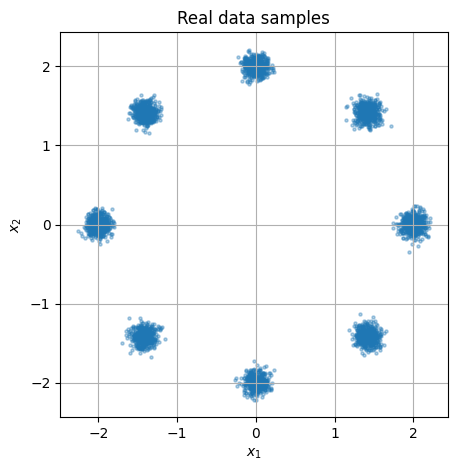

In [9]:
def sample_real(n, num_modes=8, radius=2.0, noise_scale=0.08):
    # Sample real data from clusters arranged on a circle.
    angles = 2.0 * np.pi * np.arange(num_modes) / num_modes
    centers = np.stack([np.cos(angles), np.sin(angles)], axis=1).astype(np.float32)
    centers = radius * centers

    indices = np.random.randint(0, num_modes, size=n)
    noise = noise_scale * np.random.randn(n, 2).astype(np.float32)

    return centers[indices] + noise


real_samples = sample_real(4000, num_modes=8)

plt.figure(figsize=(5, 5))
plt.scatter(real_samples[:, 0], real_samples[:, 1], s=5, alpha=0.35)
plt.axis("equal")
plt.grid(True)
plt.title("Real data samples")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

1. 8 clusters
2. There are 4 clusters
3. Each sample is only a 2D point

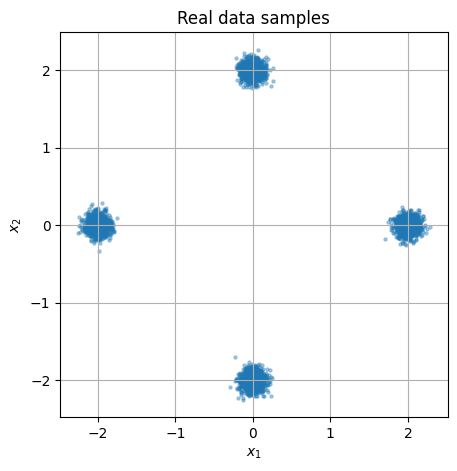

In [11]:
def sample_real(n, num_modes=4, radius=2.0, noise_scale=0.08):
    # Sample real data from clusters arranged on a circle.
    angles = 2.0 * np.pi * np.arange(num_modes) / num_modes
    centers = np.stack([np.cos(angles), np.sin(angles)], axis=1).astype(np.float32)
    centers = radius * centers

    indices = np.random.randint(0, num_modes, size=n)
    noise = noise_scale * np.random.randn(n, 2).astype(np.float32)

    return centers[indices] + noise


real_samples = sample_real(4000, num_modes=4)

plt.figure(figsize=(5, 5))
plt.scatter(real_samples[:, 0], real_samples[:, 1], s=5, alpha=0.35)
plt.axis("equal")
plt.grid(True)
plt.title("Real data samples")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

## Exercise 2: Latent noise

The generator starts from simple noise

$$
z\sim \mathcal N(0,I).
$$

For this exercise,

$$
z\in\mathbb R^2.
$$

The generator will learn a map

$$
G_\theta:\mathbb R^2\to\mathbb R^2.
$$

### Task

Run the cell and compare the noise distribution with the real data distribution.

Answer:

1. Is the noise distribution already shaped like the real distribution?


    It is a simple cloud around the center, while the real data has several separated clusters.
3. What does the generator need to learn?



    How to transform simple noise into points that look like samples.

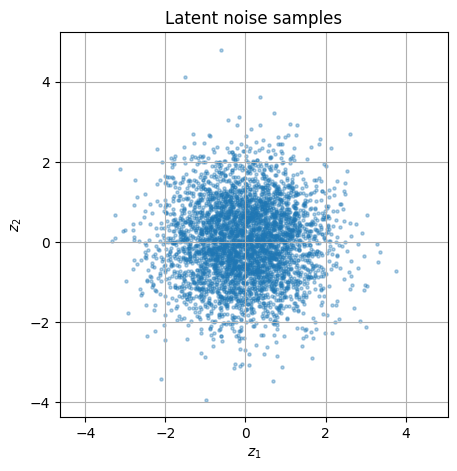

In [12]:
def sample_noise(n, z_dim=2):
    return np.random.randn(n, z_dim).astype(np.float32)


z = sample_noise(4000, z_dim=2)

plt.figure(figsize=(5, 5))
plt.scatter(z[:, 0], z[:, 1], s=5, alpha=0.35)
plt.axis("equal")
plt.grid(True)
plt.title("Latent noise samples")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

## Exercise 3: The discriminator output

The discriminator outputs a number between \(0\) and \(1\):

$$
D_\phi(x)\in(0,1).
$$

We interpret this as

$$
D_\phi(x)\approx \Pr(\mathrm{real}\mid x).
$$

To produce a number between \(0\) and \(1\), we use the sigmoid function

$$
\sigma(t)=\frac{1}{1+e^{-t}}.
$$

### Task

Complete the sigmoid function below.

In [14]:
def sigmoid(logits):
    # STUDENT TODO:
    # Implement sigma(t) = 1 / (1 + exp(-t)).
    # Hint: use np.exp.
    return 1.0 / (1.0 + np.exp(-logits))


test_values = np.array([-5.0, 0.0, 5.0])
print("sigmoid([-5, 0, 5]) =", sigmoid(test_values))

sigmoid([-5, 0, 5]) = [0.00669285 0.5        0.99330715]


## Exercise 4: Binary cross-entropy

The discriminator is a binary classifier.

For a label

$$
y\in\{0,1\}
$$

and a predicted probability

$$
p\in(0,1),
$$

the binary cross-entropy is

$$
\ell(p,y)
=
-\left[y\log p+(1-y)\log(1-p)\right].
$$

If \(y=1\), the loss is small when \(p\) is close to \(1\).  
If \(y=0\), the loss is small when \(p\) is close to \(0\).

### Task

Complete the binary cross-entropy function.

In [15]:
def binary_cross_entropy(probabilities, labels):
    eps = 1e-8

    # STUDENT TODO:
    # Return the mean value of
    # -[y log(p) + (1-y) log(1-p)].
    probabilities = np.clip(probabilities, eps, 1.0 - eps)
    loss = -(labels * np.log(probabilities) + (1.0 - labels) * np.log(1.0 - probabilities))
    return np.mean(loss)


p_test = np.array([0.9, 0.2, 0.8])
y_test_small = np.array([1.0, 0.0, 1.0])

print("BCE test value:", binary_cross_entropy(p_test, y_test_small))

BCE test value: 0.18388253942874858


## 5. Provided neural-network code

The next cell gives a small neural network class.

You do not need to write the backpropagation code in this exercise. It is provided so that we can focus on the GAN idea.

Both the generator and discriminator will be small multilayer perceptrons.

The generator is

$$
G_\theta:\mathbb R^2\to\mathbb R^2.
$$

The discriminator produces one logit

$$
a_\phi(x)\in\mathbb R,
$$

and then the sigmoid converts it into

$$
D_\phi(x)=\sigma(a_\phi(x)).
$$

In [16]:
class MLP:
    # Minimal multilayer perceptron with manual backpropagation and Adam updates.

    def __init__(self, sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.sizes = sizes
        self.num_layers = len(sizes) - 1

        self.params = {}
        for layer in range(self.num_layers):
            fan_in = sizes[layer]
            fan_out = sizes[layer + 1]
            scale = np.sqrt(2.0 / fan_in)

            self.params[f"W{layer}"] = (
                0.7 * rng.normal(0.0, scale, size=(fan_in, fan_out))
            ).astype(np.float32)

            self.params[f"b{layer}"] = np.zeros(fan_out, dtype=np.float32)

        self.adam_state = {
            name: [np.zeros_like(value), np.zeros_like(value)]
            for name, value in self.params.items()
        }
        self.adam_step = 0

    @staticmethod
    def leaky_relu(x):
        return np.where(x > 0.0, x, 0.2 * x)

    @staticmethod
    def d_leaky_relu(x):
        return np.where(x > 0.0, 1.0, 0.2).astype(np.float32)

    def forward(self, x):
        activations = [x]
        preactivations = []

        h = x
        for layer in range(self.num_layers):
            W = self.params[f"W{layer}"]
            b = self.params[f"b{layer}"]

            pre = h @ W + b
            preactivations.append(pre)

            if layer < self.num_layers - 1:
                h = self.leaky_relu(pre)
            else:
                h = pre

            activations.append(h)

        cache = (activations, preactivations)
        return h, cache

    def backward(self, output_gradient, cache):
        activations, preactivations = cache
        gradients = {}

        grad = output_gradient

        for layer in reversed(range(self.num_layers)):
            if layer < self.num_layers - 1:
                grad = grad * self.d_leaky_relu(preactivations[layer])

            previous_activation = activations[layer]

            gradients[f"W{layer}"] = previous_activation.T @ grad
            gradients[f"b{layer}"] = grad.sum(axis=0)

            grad = grad @ self.params[f"W{layer}"].T

        input_gradient = grad
        return gradients, input_gradient

    def step_adam(self, gradients, lr=1e-3, beta1=0.5, beta2=0.999, eps=1e-8):
        self.adam_step += 1

        for name, grad in gradients.items():
            m, v = self.adam_state[name]

            m[:] = beta1 * m + (1.0 - beta1) * grad
            v[:] = beta2 * v + (1.0 - beta2) * (grad * grad)

            m_hat = m / (1.0 - beta1 ** self.adam_step)
            v_hat = v / (1.0 - beta2 ** self.adam_step)

            self.params[name] -= lr * m_hat / (np.sqrt(v_hat) + eps)


print("MLP class loaded.")

MLP class loaded.


## Exercise 5: Create the generator and discriminator

We use the architectures

$$
G_\theta: 2\to 32\to 32\to 2
$$

and

$$
D_\phi: 2\to 32\to 32\to 1.
$$

### Task

Run the cell and answer:

1. Why does the generator output have dimension \(2\)?
2. Why does the discriminator output have dimension \(1\)?
3. Which network produces fake data?
4. Which network tries to detect fake data?

1. Because it produces a 2D point, just like the real data
2. It gives one real/fake score for each point
3. The generator $G_\theta$
4. The discriminator $D_\phi$

In [17]:
G = MLP([2, 32, 32, 2], seed=1)
D = MLP([2, 32, 32, 1], seed=2)

print("Generator:     2 -> 32 -> 32 -> 2")
print("Discriminator: 2 -> 32 -> 32 -> 1")

Generator:     2 -> 32 -> 32 -> 2
Discriminator: 2 -> 32 -> 32 -> 1


## 6. GAN losses

The discriminator sees real and fake samples.

For real samples \(x\sim p_{\mathrm{data}}\), it should output \(1\).  
For fake samples \(G_\theta(z)\), it should output \(0\).

The discriminator loss is

$$
L_D
=
-\mathbb E_{x\sim p_{\mathrm{data}}}\log D_\phi(x)
-\mathbb E_{z\sim p_z}\log\left(1-D_\phi(G_\theta(z))\right).
$$

The generator wants fake samples to be called real, so we use

$$
L_G
=
-\mathbb E_{z\sim p_z}\log D_\phi(G_\theta(z)).
$$

In code, expectations are replaced by batch averages.

## Exercise 6: Train the GAN

The training alternates:

1. update \(D\) to separate real from fake;
2. update \(G\) to fool \(D\).

### Task

Run the training cell.

Then answer:

1. Does the generator become perfect?
2. Do the losses decrease smoothly?
3. Why should we not expect GAN losses to behave like ordinary supervised-learning losses?

In [19]:
def train_gan(num_steps=2500, batch_size=256, lr_D=1e-3, lr_G=1e-3):
    history = {
        "step": [],
        "D_loss": [],
        "G_loss": [],
        "D_real_mean": [],
        "D_fake_mean": [],
    }

    snapshots = {}

    for step in range(num_steps + 1):
        # Step A: update discriminator.
        real_batch = sample_real(batch_size)
        noise_batch = sample_noise(batch_size)

        fake_batch, _ = G.forward(noise_batch)

        real_logits, real_cache = D.forward(real_batch)
        fake_logits, fake_cache = D.forward(fake_batch)

        D_real = sigmoid(real_logits)
        D_fake = sigmoid(fake_logits)

        D_loss = -np.mean(
            np.log(D_real + 1e-8)
            +
            np.log(1.0 - D_fake + 1e-8)
        )

        # For sigmoid + binary cross-entropy, gradient w.r.t. logits is p-y.
        d_real_logits = (D_real - 1.0) / batch_size
        d_fake_logits = (D_fake - 0.0) / batch_size

        D_grads_real, _ = D.backward(d_real_logits, real_cache)
        D_grads_fake, _ = D.backward(d_fake_logits, fake_cache)

        D_grads = {
            name: D_grads_real[name] + D_grads_fake[name]
            for name in D_grads_real
        }

        D.step_adam(D_grads, lr=lr_D)

        # Step B: update generator.
        noise_batch = sample_noise(batch_size)
        fake_batch, G_cache = G.forward(noise_batch)

        fake_logits, fake_cache = D.forward(fake_batch)
        D_fake_for_G = sigmoid(fake_logits)

        G_loss = -np.mean(np.log(D_fake_for_G + 1e-8))

        # Generator wants fake label 1.
        d_fake_logits_for_G = (D_fake_for_G - 1.0) / batch_size

        _, d_fake_points = D.backward(d_fake_logits_for_G, fake_cache)
        G_grads, _ = G.backward(d_fake_points, G_cache)

        G.step_adam(G_grads, lr=lr_G)

        if step % 250 == 0:
            history["step"].append(step)
            history["D_loss"].append(float(D_loss))
            history["G_loss"].append(float(G_loss))
            history["D_real_mean"].append(float(D_real.mean()))
            history["D_fake_mean"].append(float(D_fake_for_G.mean()))

        if step in [0, 500, 1000, 1500, 2500]:
            generated_snapshot, _ = G.forward(sample_noise(3000))
            snapshots[step] = generated_snapshot

    return history, snapshots


history, snapshots = train_gan(num_steps=2500)

print("Training complete.")
print("Final discriminator loss:", round(history["D_loss"][-1], 4))
print("Final generator loss:", round(history["G_loss"][-1], 4))
print("Final mean D(real):", round(history["D_real_mean"][-1], 4))
print("Final mean D(fake):", round(history["D_fake_mean"][-1], 4))

Training complete.
Final discriminator loss: 1.3718
Final generator loss: 0.7995
Final mean D(real): 0.5043
Final mean D(fake): 0.4851


1. It may learn to produce samples that look similar to the real data distribution, but it usually does not generate perfect samples.

2. GAN training is unstable because the generator and discriminator are trained against each other.

3. Target is constantly changing. When the discriminator improves, the generator's task becomes harder. When the generator improves, the discriminator's task changes too.

## Exercise 7: Inspect the losses

GAN losses may oscillate because the two networks are competing.

If the discriminator is very strong, the generator receives poor learning signals. If the generator improves, the discriminator's problem changes.

### Task

Run the cell and describe the curves in words.

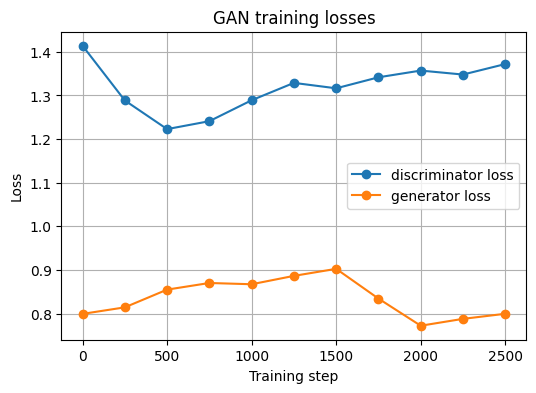

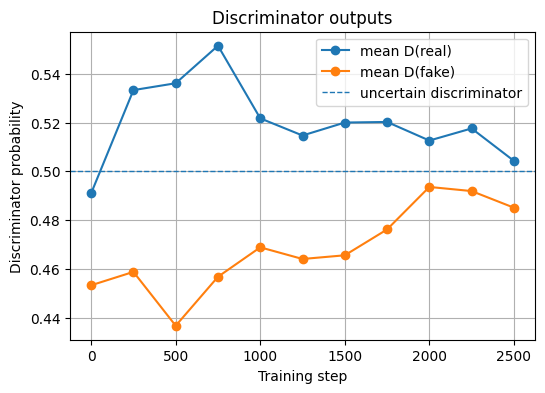

In [20]:
steps = np.array(history["step"])

plt.figure(figsize=(6, 4))
plt.plot(steps, history["D_loss"], marker="o", label="discriminator loss")
plt.plot(steps, history["G_loss"], marker="o", label="generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN training losses")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(steps, history["D_real_mean"], marker="o", label="mean D(real)")
plt.plot(steps, history["D_fake_mean"], marker="o", label="mean D(fake)")
plt.axhline(0.5, linestyle="--", linewidth=1, label="uncertain discriminator")
plt.xlabel("Training step")
plt.ylabel("Discriminator probability")
plt.title("Discriminator outputs")
plt.grid(True)
plt.legend()
plt.show()

The discriminator loss first goes down, but later increases again and changes during training. The generator loss also changes up and down instead of steadily decreasing.

In the real discriminator output plot, is usually slightly above $0.5$, while fake is slightly below $0.5$. Near the end, both values are close to $0.5$, which means that the discriminator is uncertain and has difficulty separating real and fake samples.

## Exercise 8: Compare real and generated samples

The most important diagnostic is visual. A successful generator should produce samples in roughly the same regions as the real data.

### Task

Run the cell and answer:

1. At the beginning, where are the generated samples?
2. By the end, do they move toward the real clusters?
3. Does the generator cover all modes equally?
4. If not, what failure mode might this suggest?

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


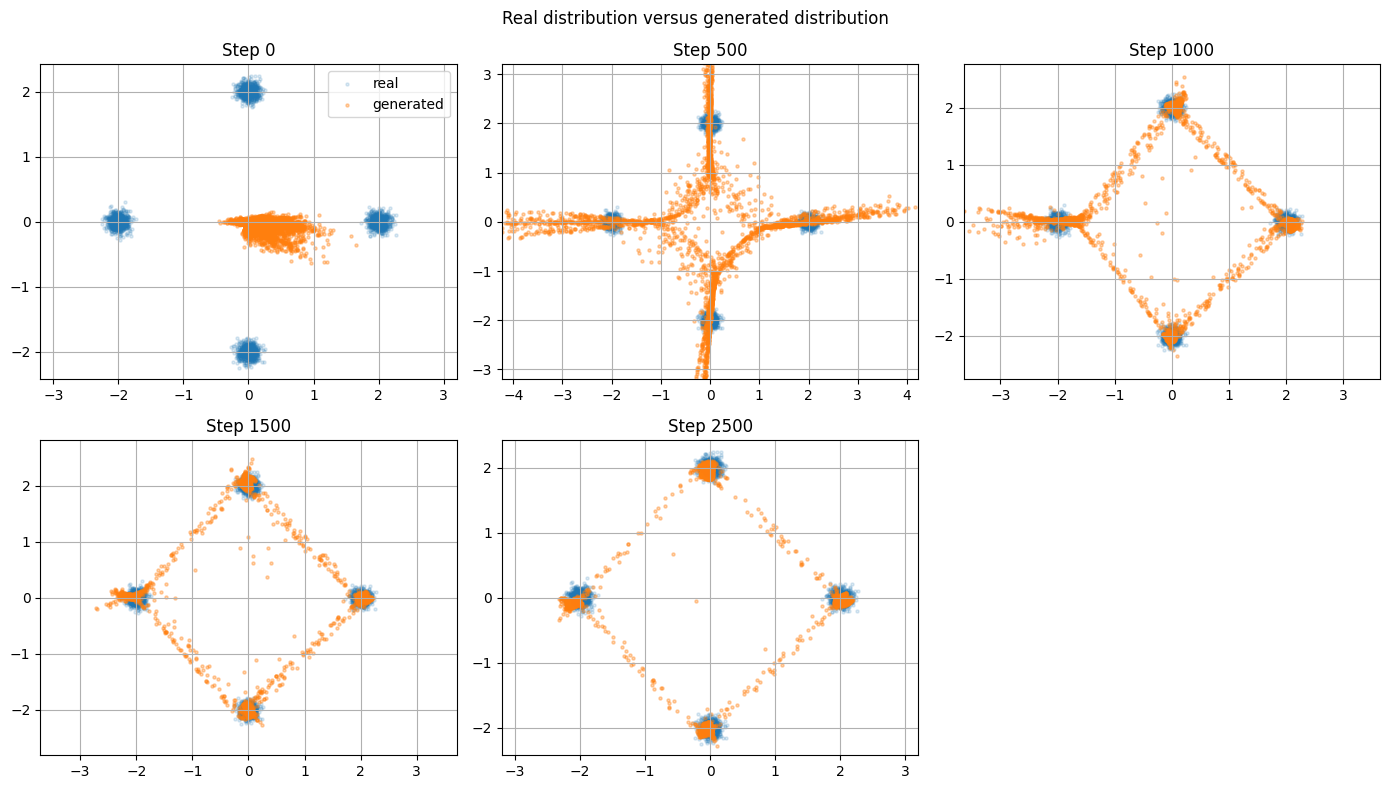

In [21]:
real_for_plot = sample_real(3000)
snapshot_steps = [0, 500, 1000, 1500, 2500]

plt.figure(figsize=(14, 8))

for k, step in enumerate(snapshot_steps):
    plt.subplot(2, 3, k + 1)
    fake = snapshots[step]

    plt.scatter(real_for_plot[:, 0], real_for_plot[:, 1], s=5, alpha=0.15, label="real")
    plt.scatter(fake[:, 0], fake[:, 1], s=5, alpha=0.35, label="generated")

    plt.axis("equal")
    plt.xlim(-3.2, 3.2)
    plt.ylim(-3.2, 3.2)
    plt.grid(True)
    plt.title(f"Step {step}")

    if k == 0:
        plt.legend(loc="upper right")

plt.suptitle("Real distribution versus generated distribution")
plt.tight_layout()
plt.show()

1. In the middle
2. Most of them are in the place of clusters but some stay in between two clusters
3. Yes
4. If some clusters are missing or much weaker, this suggests that the generator learns only part of the data distribution instead of the full

## Exercise 9: Final interpretation

Answer these questions in your own words.

1. What is the role of \(z\)?

Provide random input noise for the generator

2. What does \(G_\theta(z)\) represent?

Fake sample produced by the generator

3. What does \(D_\phi(x)\) estimate?

How likely a sample is to be real

4. What does \(p_G\approx p_{\mathrm{data}}\) mean?

Distribution of generated samples becomes similar to the real data distribution

5. Why is this a generative model rather than a classifier?

It creates new samples

6. What would change if \(x\) were an image instead of a two-dimensional point?


The generator and discriminator would need to be larger

## Optional extension

Change one of the following:

- `num_modes` in `sample_real`,
- generator width \(32\to 8\) or \(32\to 64\),
- number of training steps,
- latent dimension \(2\to 1\).

Then rerun the notebook and describe the effect.